In [1]:
import os
import sys

os.chdir("..")
sys.path.append(os.getcwd())

from experiment_runner import run_all_experiments
from analysis import *

In [2]:
search_space = {
    "model": ["cnn", "resnet18"],

    "common": {
        "batch_size": [64, 128],
    },

    "cnn": {
        "lr": (1e-4, 3e-3, "log"),
        "weight_decay": (1e-5, 1e-3, "log"),
        "dropout": [0.3, 0.5],
    },

    "resnet18": {
        "lr": (1e-5, 5e-4, "log"),
        "weight_decay": (1e-6, 3e-4, "log"),
        "dropout": [0, 0.1, 0.3],
    }
}

In [3]:
run_all_experiments(
    search_space,
    n_samples=20,
    folder="exp1_hparams"
)

Seed: 0, Config: {"model": "cnn", "batch_size": 64, "lr": 0.00010887894853149385, "weight_decay": 3.5486129798045086e-05, "dropout": 0.3}
Epoch 1: train=1.7784, val=1.5521, acc=0.5050
Epoch 2: train=1.5564, val=1.3958, acc=0.5861
Epoch 3: train=1.4622, val=1.3262, acc=0.6234
Epoch 4: train=1.3978, val=1.2731, acc=0.6493
Epoch 5: train=1.3497, val=1.2337, acc=0.6670
Epoch 6: train=1.3095, val=1.1986, acc=0.6854
Epoch 7: train=1.2758, val=1.1789, acc=0.6936
Epoch 8: train=1.2486, val=1.1462, acc=0.7096
Epoch 9: train=1.2232, val=1.1419, acc=0.7116
Epoch 10: train=1.2005, val=1.1194, acc=0.7220
Epoch 11: train=1.1824, val=1.1084, acc=0.7285
Epoch 12: train=1.1675, val=1.0907, acc=0.7344
Epoch 13: train=1.1515, val=1.0894, acc=0.7390
Epoch 14: train=1.1369, val=1.0726, acc=0.7427
Epoch 15: train=1.1237, val=1.0697, acc=0.7479
Epoch 16: train=1.1103, val=1.0459, acc=0.7573
Epoch 17: train=1.0981, val=1.0413, acc=0.7600
Epoch 18: train=1.0864, val=1.0358, acc=0.7619
Epoch 19: train=1.0765, v

In [2]:
df = load_results("./results/exp1_hparams")
df.head()

,model,batch_size,lr,weight_decay,dropout,val_acc,test_acc,val_macro_f1,test_macro_f1,val_f1_mean,test_f1_mean
0,resnet18,64,0.000028,0.000004,0.3,0.898422,0.897044,0.898264,0.896930,0.898264,0.896930
1,resnet18,64,0.000028,0.000004,0.3,0.898122,0.896533,0.898025,0.896497,0.898025,0.896497
2,resnet18,64,0.000028,0.000004,0.3,0.898322,0.895700,0.898225,0.895654,0.898225,0.895654
3,cnn,64,0.000352,0.000026,0.5,0.821267,0.818667,0.820863,0.818444,0.820863,0.818444
4,cnn,64,0.000352,0.000026,0.5,0.822344,0.819067,0.821991,0.818792,0.821991,0.818792


In [3]:
summary = summarize(df, ["model", "lr", "weight_decay", "dropout", "batch_size"])
summary.head(10)

,model,lr,weight_decay,dropout,batch_size,mean_acc,std_acc,mean_f1,std_f1,mean_val_acc,mean_val_f1
27,resnet18,0.000043,0.000003,0.3,64,0.898759,0.000558,0.898682,0.000527,0.899893,0.899769
31,resnet18,0.000116,0.000092,0.1,64,0.898415,0.000934,0.898353,0.000914,0.899500,0.899420
28,resnet18,0.000045,0.000030,0.1,64,0.898407,0.000933,0.898280,0.001036,0.899815,0.899635
25,resnet18,0.000028,0.000145,0.1,64,0.898063,0.000267,0.897953,0.000218,0.899511,0.899328
24,resnet18,0.000028,0.000004,0.3,64,0.896426,0.000679,0.896360,0.000649,0.898289,0.898171
30,resnet18,0.000104,0.000016,0.0,64,0.891870,0.007477,0.891813,0.007439,0.893481,0.893356
26,resnet18,0.000041,0.000295,0.0,128,0.891189,0.007739,0.890950,0.007849,0.892848,0.892549
29,resnet18,0.000073,0.000002,0.3,64,0.889930,0.003731,0.889955,0.003642,0.891611,0.891585
23,resnet18,0.000017,0.000015,0.3,64,0.887959,0.000514,0.887759,0.000486,0.889396,0.889134
20,resnet18,0.000013,0.000150,0.0,64,0.886704,0.000421,0.886548,0.000437,0.888633,0.888426


In [5]:
best = get_best_configs(df, top_k=5)
best

,model,batch_size,lr,weight_decay,dropout,val_acc,test_acc,val_macro_f1,test_macro_f1,val_f1_mean,test_f1_mean
33,resnet18,128,0.000041,0.000295,0.0,0.900856,0.900078,0.900682,0.899972,0.900682,0.899972
109,resnet18,64,0.000104,0.000016,0.0,0.900867,0.900044,0.900768,0.900002,0.900768,0.900002
97,resnet18,64,0.000116,0.000092,0.1,0.900133,0.899489,0.900044,0.899409,0.900044,0.899409
106,resnet18,64,0.000043,0.000003,0.3,0.900433,0.899400,0.900280,0.899282,0.900280,0.899282
26,resnet18,64,0.000045,0.000030,0.1,0.900633,0.899222,0.900588,0.899214,0.900588,0.899214


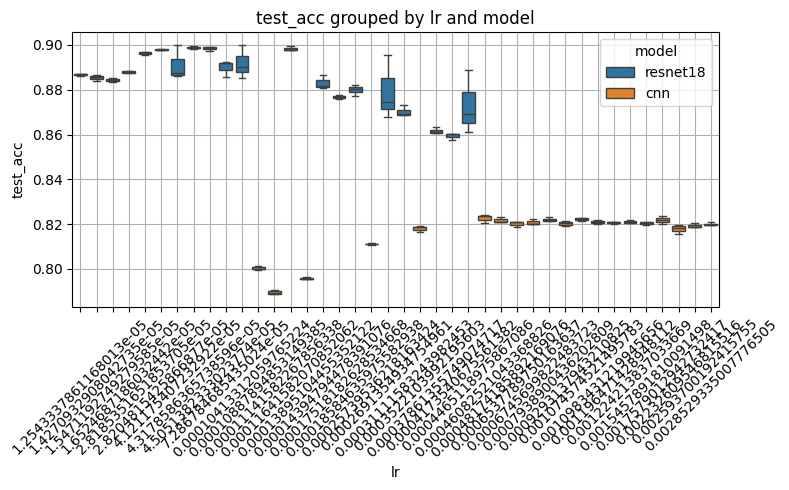

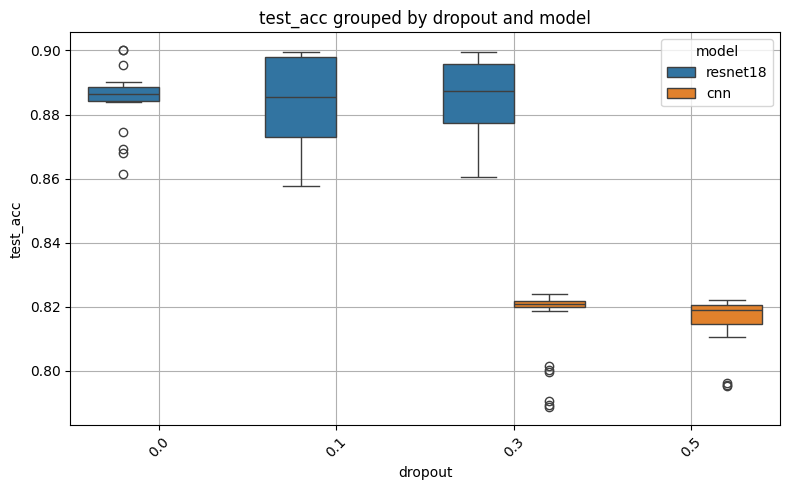

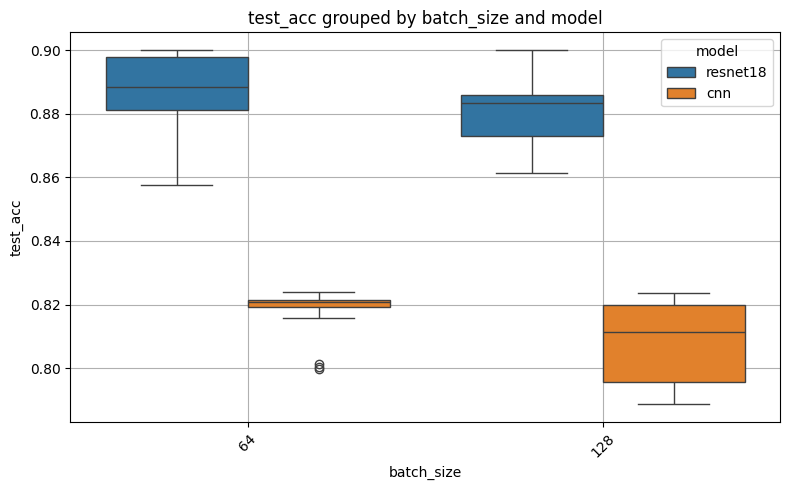

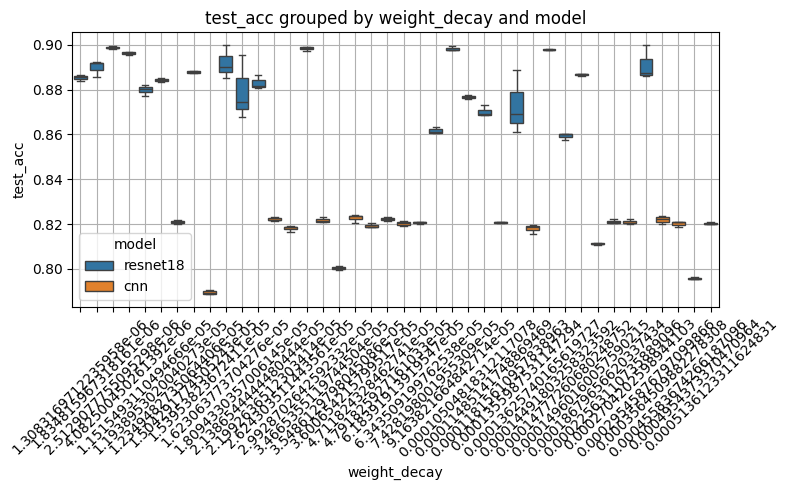

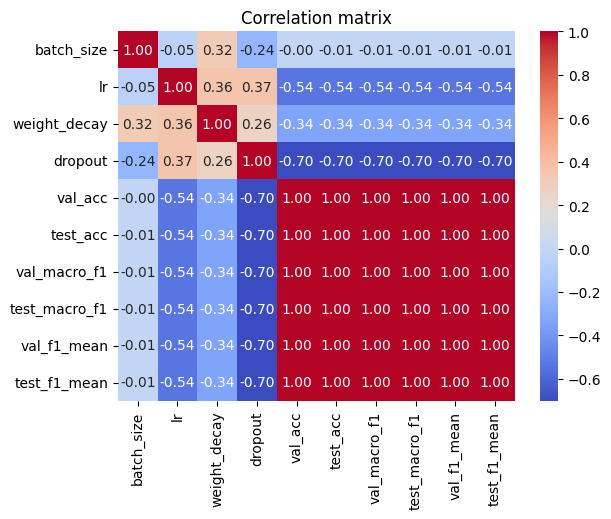

In [7]:
boxplot_metric(df, x="lr")
boxplot_metric(df, x="dropout")
boxplot_metric(df, x="batch_size")

boxplot_metric(df, x="weight_decay")
correlation_plot(df)